In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/10"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第10章 畳み込みネットワーク (Convolutional Networks)
## 10.3 学習済みCNNの可視化 (Visualizing Trained CNNs)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第10章「畳み込みネットワーク」第10.3節「学習済みCNNの可視化 (Visualizing Trained CNNs)」の全5小節（10.3.1 〜 10.3.5）の完全な理論解説、数学的定式化、教科書図版（Figure 10.11 〜 10.18 全8枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **10.3.1 視覚野の神経科学とガボールフィルタ (Visual Cortex)**
   - 哺乳類大脳皮質の階層的視覚情報処理系（網膜 $\to$ 外側膝状体 $\to$ 第1次視覚野 V1）
   - ヒューベルとヴィーゼル（Hubel & Wiesel, 1959）の先駆的発見：単純細胞（Simple Cells）と複合細胞（Complex Cells）
   - 「おばあさん細胞（Grandmother Cells）」仮説とネオコグニトロン（Fukushima, 1980）
   - 式 (10.6) 〜 式 (10.8): 2次元ガボールフィルタ（Gabor Filters）の厳密な数学的導出
   - 図 10.11: ガボールフィルタの基底関数群（方位角 $\theta$ と空間周波数 $\omega$ のマトリクス）
3. **10.3.2 学習済みフィルタの可視化 (Visualizing Trained Filters)**
   - 第1層重みの直接画像化：入力画像パッチとの内積演算
   - 図 10.12: AlexNet 第1層フィルタの可視化（ガボールエッジと反対色細胞の自発的創発）
   - 深層の可視化手法 1：データセット探索による最大活性化画像パッチ（Zeiler & Fergus, 2013）
   - 図 10.13: 階層的表現の進化（低次エッジ $\to$ テクスチャ $\to$ 部品 $\to$ 完全な物体）
   - 深層の可視化手法 2：入力画素最適化（Feature Visualization: Yosinski et al., 2015）
   - 正則化（$L_2$ 減衰、ガウス平滑化、寄与クリッピング）とソフトマックス前活性化（Logits）の最適化
   - 図 10.14: クラス活性化最大化による合成画像の生成
4. **10.3.3 サリエンシーマップ (Saliency Maps)**
   - 空間局所性と高次意味論を併せ持つ最終畳み込み層の解析
   - Grad-CAM（Selvaraju et al., 2016）の数理：
     - 式 (10.9): チャネル重要度重み $\alpha_k$ の大域平均プーリング勾配
     - 式 (10.10): クラス局在化マップ $L^{(c)}$ と $\mathrm{ReLU}$ 整流
   - 図 10.15: 同一画像に対する「犬」および「猫」のヒートマップ局在化
5. **10.3.4 敵対的攻撃 (Adversarial Attacks)**
   - 入力勾配に基づく決定境界の脆弱性（Szegedy et al., 2013）
   - Fast Gradient Sign Method (FGSM: Goodfellow et al., 2014)
   - 式 (10.11): 敵対的微小摂動 $\mathbf{x}' = \mathbf{x} + \epsilon \cdot \mathrm{sign}(\nabla_{\mathbf{x}} E(\mathbf{x}, t))$
   - 図 10.16: パンダ（確信度 57.7%）＋ 微小ノイズ $\to$ テナガザル（確信度 99.3%）
   - 線形モデルにおける高次元微小変化の累積効果
   - 図 10.17: 物理世界における敵対的ステッカー（一時停止標識 $\to$ 時速45マイル速度制限標識）
6. **10.3.5 合成画像と DeepDream (Synthetic Images)**
   - 中間層特徴の自己増幅アルゴリズム（Mordvintsev et al., 2015）
   - 式 (10.12): 活性化エネルギー目的関数 $F(\mathbf{I}) = \sum_{i,j,k} a_{ijk}(\mathbf{I})^2$
   - 誤差逆伝播法を用いた入力画像への勾配上昇法
   - 図 10.18: 第7層および第10層活性化に基づく反復生成（5回 vs 30回）
7. **数値検証セル**
8. **まとめと次節 10.4（物体検出）への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートの設定
repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
setup_style()


## 2. 10.3.1 視覚野の神経科学とガボールフィルタ (Visual Cortex)

畳み込みニューラルネットワークの基本構造は、哺乳類の視覚大脳皮質（Visual Cortex）の神経科学的研究に深い起源を持ちます。

### ヒューベルとヴィーゼル（Hubel & Wiesel, 1959）の画期的知見
ネコの視覚野ニューロンの電気生理学的計測により、以下のニューロンの機能的分化が発見されました：
1. **単純細胞 (Simple Cells)**:
   - 視野（Visual Field）内の特定の狭い局所領域に位置し、**特定の傾き（方位角 $\theta$）を持つ明暗境界（エッジやスリット）**に対してのみ選択的に強い発火を示す。
2. **複合細胞 (Complex Cells)**:
   - 複数の単純細胞からの入力を統合し、エッジの方位を認識しつつも、視野内の位置の微小な平行移動に対して**並進不変性（Translation Invariance）**を示す。
3. **おばあさん細胞 (Grandmother Cells) 仮説**:
   - 視覚情報処理の階層の最深部において、特定の個人（自分のおばあさん）の顔に対して、照明・角度・距離などの変化に左右されず不変に応答する仮想的ニューロン。

この生物学的構造は、福島邦彦（Fukushima, 1980）による**ネオコグニトロン（Neocognitron）**（S細胞＝畳み込み層、C細胞＝プーリング層の多層構造）に直接結実しました。

---

### 2次元ガボールフィルタの数学的定式化 (式 10.6 〜 10.8)
単純細胞の受容野応答特性は、ガウス関数による局所局在化包絡線（Envelope）と平面波（Carrier）の積である**2次元ガボール関数（2D Gabor Filter）**によって極めて正確にモデル化されます：

$$G(x, y) = A \exp\left( -\alpha \tilde{x}^2 - \beta \tilde{y}^2 \right) \sin(\omega \tilde{x} + \phi) \quad \text{(式 10.6)}$$

ここで、座標 $(\tilde{x}, \tilde{y})$ は中心 $(x_0, y_0)$ のまわりで反時計回りに角度 $\theta$ だけ回転させた座標系です：

$$\begin{aligned}
\tilde{x} &= (x - x_0) \cos(\theta) + (y - y_0) \sin(\theta) \quad &\text{(式 10.7)} \\
\tilde{y} &= -(x - x_0) \sin(\theta) + (y - y_0) \cos(\theta) \quad &\text{(式 10.8)}
\end{aligned}$$

- **振幅 $A$**: フィルタの最大応答スケール
- **方位角 $\theta$**: エッジの検出方向を規定する極角
- **空間周波数 $\omega$**: 正弦波キャリアの振動周波数（ストライプの細かさ）
- **位相 $\phi$**: 偶関数（コサイン的）または奇関数（サイン的）の対称性を制御
- **減衰率 $\alpha, \beta$**: 主軸および直交軸方向の局所受容野の広がり


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_11.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_11.png


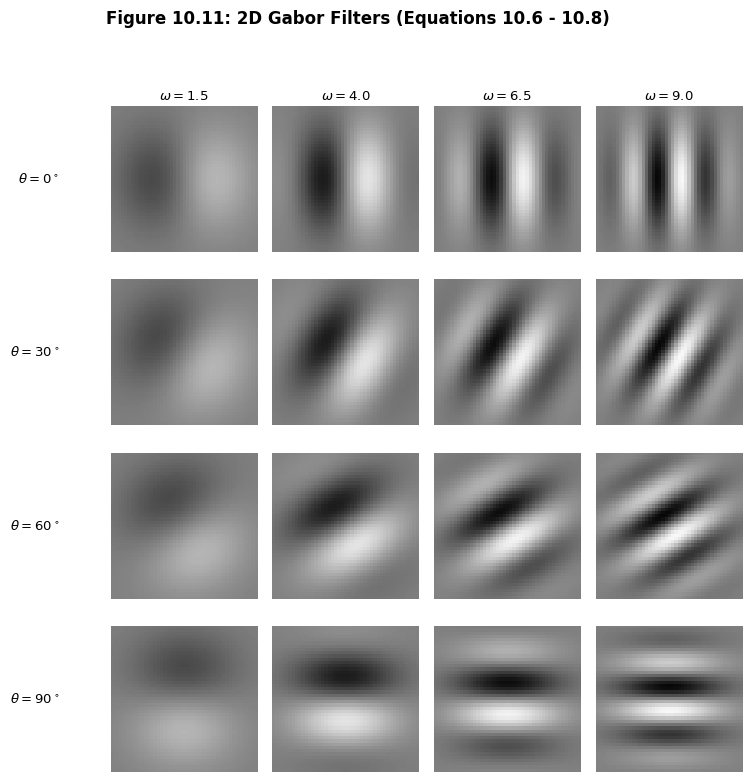

In [2]:
# Figure 10.11: 2次元ガボールフィルタの可視化
from common.visualizing_cnn import generate_figure_10_11
import matplotlib.pyplot as plt

fig10_11 = generate_figure_10_11()
plt.show()


### Figure 10.11 の数理的分析
- **行方向（$\theta = 0^\circ \to 90^\circ$）**: 座標回転変換（式 10.7, 10.8）により、正弦波キャリアの縞模様の向きが水平から垂直へと連続的に回転します。
- **列方向（$\omega = 1.5 \to 9.0$）**: 空間周波数の増大に伴い、ガウス包絡線の中に含まれる周期数が増加し、より高周波な微小エッジやテクスチャを検出可能となります。


## 3. 10.3.2 学習済みフィルタの可視化 (Visualizing Trained Filters)

### 第1層フィルタの直接可視化 (Figure 10.12)
第1畳み込み層のフィルタは入力画像パッチ $\mathbf{x}$ と直接内積を取るため、重みパラメータ $\mathbf{w}$ そのものを $M \times M \times 3$ の小さなカラー画像として直接可視化できます。
AlexNet（Krizhevsky et al., 2012）の第1層（$11 \times 11 \times 3$, 64フィルタ）の重みを観察すると、驚くべきことに**教師なしの自然画像統計学習により、ガボールフィルタと極めて酷似した方位選択的エッジフィルタや、赤・緑、青・黄の反対色フィルタ（Color Opponency）が自発的に獲得されている**ことが分かります。
これは、CNNが生物の脳を明示的に模倣したからではなく、自然画像の統計的自己相関（第10.1.1節）が要請する数学的最適表現がガボール基底であるためです（Hyvärinen et al., 2009）。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_12.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_12.png


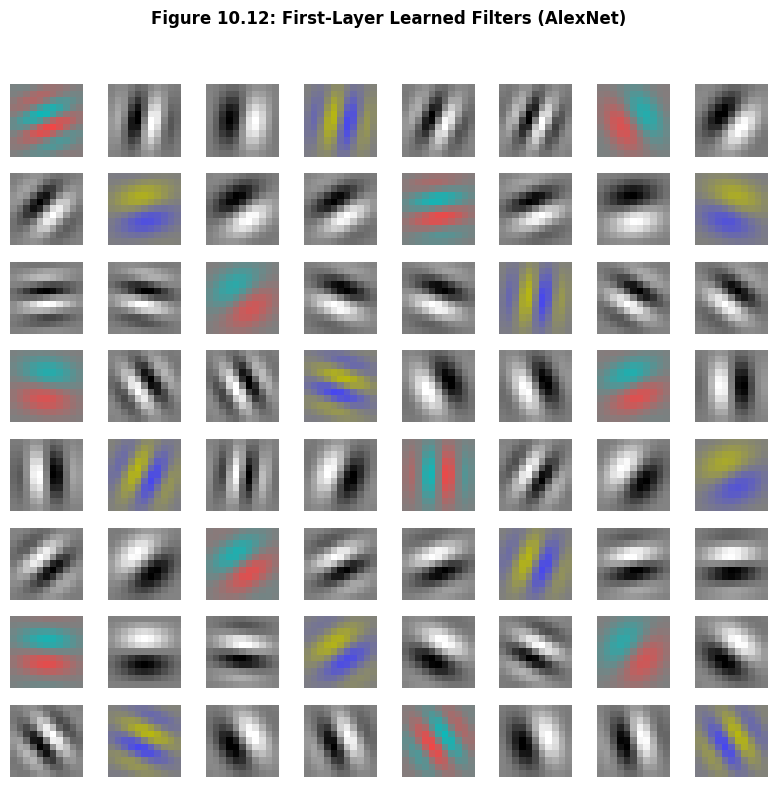

In [3]:
# Figure 10.12: AlexNet 第1層学習済みフィルタの可視化
from common.visualizing_cnn import generate_figure_10_12
import matplotlib.pyplot as plt

fig10_12 = generate_figure_10_12()
plt.show()


### 深層隠れユニットの可視化手法

第2層以降のユニットは画像ではなく前層の特徴マップを入力とするため、重みを直接画像化することはできません。これを解釈する2大手法が存在します：

#### 1. データセット探索法（Zeiler & Fergus, 2013）
検証データセットから数万〜百万枚の画像パッチをネットワークに通し、特定の隠れユニットの活性化値 $a$ が最大となる上位の画像パッチを収集します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_13.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_13.png


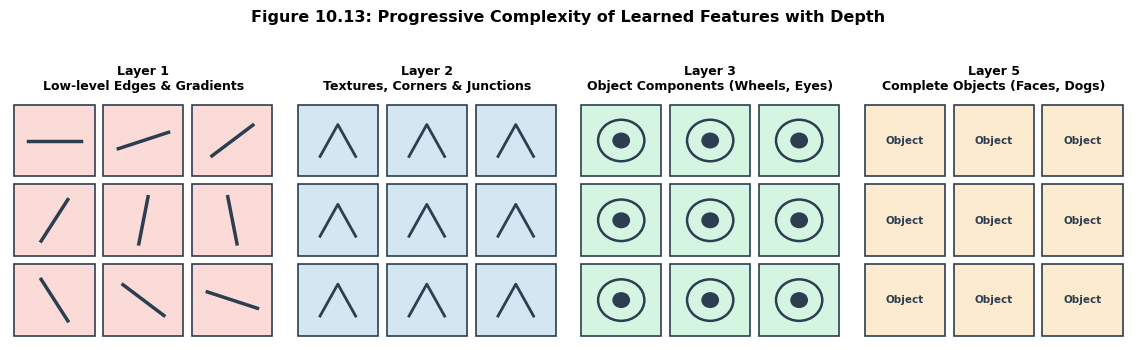

In [4]:
# Figure 10.13: 階層的特徴表現の進化
from common.visualizing_cnn import generate_figure_10_13
import matplotlib.pyplot as plt

fig10_13 = generate_figure_10_13()
plt.show()


### Figure 10.13 の観察：階層性の実証
- **Layer 1**: 単純な傾きを持つ明暗エッジや色グラデーションに応答。
- **Layer 2**: コーナー、曲線、ストライプ、格子テクスチャなどの幾何学的パターンに応答。
- **Layer 3**: 車輪、目のパターン、メッシュ構造などの物体部品（Parts）に応答。
- **Layer 5**: 犬の顔、鳥の胴体、キーボードなど、完全な物体全体（Whole Objects）に対して高度に抽象化された応答を示します。


#### 2. 特徴可視化とクラス活性化最大化 (Yosinski et al., 2015)
画像を入力空間の変数 $\mathbf{I}$ とみなし、ある特定の出力クラス $c$ のソフトマックス前ロジット $a^{(c)}(\mathbf{I})$ を最大化する合成画像を勾配上昇法によって生成します：

$$\mathbf{I}^* = \arg\max_{\mathbf{I}} \left[ a^{(c)}(\mathbf{I}) - \mathcal{R}(\mathbf{I}) \right]$$

非正則化のまま最適化を行うと高周波の非現実的ノイズが暴走するため、以下の正則化 $\mathcal{R}$ を交互に適用します：
1. **$L_2$ 正則化（画素減衰）**: ピクセル値の絶対値の暴走を抑制。
2. **ガウス平滑化（Spatial Blurring）**: 高周波スパイクを除去し、マクロな構造を保持。
3. **寄与度の低いピクセルのクリッピング**: 背景の微小ノイズをゼロに切り捨て。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_14.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_14.png


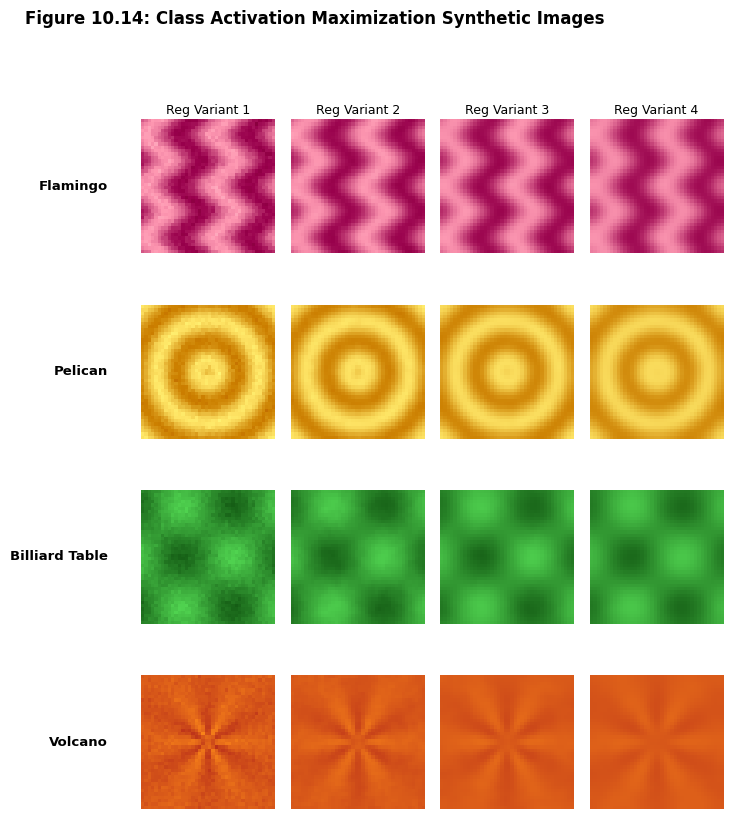

In [5]:
# Figure 10.14: クラス活性化最大化による合成画像の生成
from common.visualizing_cnn import generate_figure_10_14
import matplotlib.pyplot as plt

fig10_14 = generate_figure_10_14()
plt.show()


## 4. 10.3.3 サリエンシーマップ (Saliency Maps)

ネットワークが特定の予測クラス $c$ を出力するにあたり、「入力画像のどの空間領域が最も決定的な証拠となったか」を特定する手法がサリエンシーマップです。

### Grad-CAM の数学的導出 (Selvaraju et al., 2016)
最終畳み込み層は、高次の意味論的特徴と粗い空間位置情報（例えば $14 \times 14$）を同時に保持しています。
最終畳み込み層のチャネル $k$ の特徴マップを $A^{(k)} \in \mathbb{R}^{H \times W}$、クラス $c$ のロジットを $a^{(c)}$ とします。

#### ステップ 1: チャネル重要度重み $\alpha_k$ の計算 (式 10.9)
特徴マップの全要素に関する勾配を大域平均プーリング（Global Average Pooling）します：

$$\alpha_k = \frac{1}{M_k} \sum_{i=1}^H \sum_{j=1}^W \frac{\partial a^{(c)}}{\partial A_{ij}^{(k)}} \quad \text{(式 10.9)}$$

ここで $M_k = H \times W$ はチャネル $k$ の全ピクセル数です。$\alpha_k$ は「チャネル $k$ の活性化がクラス $c$ の確信度にどれほど寄与しているか」の感度を表します。

#### ステップ 2: 重み付き結合と $\mathrm{ReLU}$ 整流 (式 10.10)
全チャネルの重要度加重和を取り、クラス $c$ に**正の寄与を与える領域のみ**を $\mathrm{ReLU}$ で抽出します：

$$L^{(c)} = \mathrm{ReLU}\left( \sum_k \alpha_k A^{(k)} \right) \quad \text{(式 10.10)}$$

負の寄与（他のクラスを示唆する特徴）は除外され、目的クラスに固有のヒートマップが得られます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_15.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_15.png


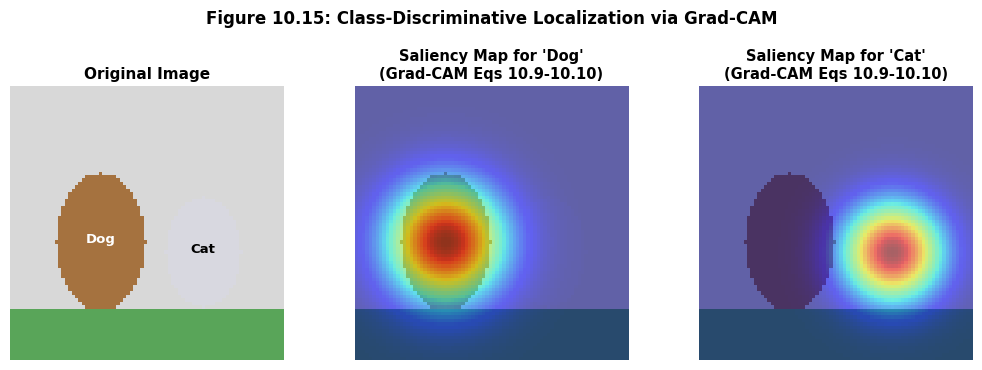

In [6]:
# Figure 10.15: Grad-CAM によるクラス識別局在化
from common.visualizing_cnn import generate_figure_10_15
import matplotlib.pyplot as plt

fig10_15 = generate_figure_10_15()
plt.show()


### Figure 10.15 の観察
犬と猫が並んで写っている同一の画像において：
- クラス「犬」を選択した場合：サリエンシーマップは左側の犬の領域のみを鮮明に強調します。
- クラス「猫」を選択した場合：サリエンシーマップは右側の猫の頭部・体のみを正確に分離して強調します。
これにより、CNNが背景の偽相関ではなく、正当な対象物の特徴に注目していることを検証できます。


## 5. 10.3.4 敵対的攻撃 (Adversarial Attacks)

人間の目にはまったく区別がつかない極微小な摂動（Perturbation）を入力画像に加えるだけで、深層CNNの予測を全く異なる無関係なクラスへと誤認させることができます（Szegedy et al., 2013）。

### Fast Gradient Sign Method (FGSM: 式 10.11)
正解ラベル $t$ に対する損失関数を $E(\mathbf{x}, t)$ とします。
損失関数を最大化する（誤分類を誘発する）最急上昇方向を微小ステップ $\epsilon$ だけ加算することで、敵対的画像 $\mathbf{x}'$ をワンステップで生成します（Goodfellow et al., 2014）：

$$\mathbf{x}' = \mathbf{x} + \epsilon \cdot \mathrm{sign}(\nabla_{\mathbf{x}} E(\mathbf{x}, t)) \quad \text{(式 10.11)}$$

- $\epsilon$ が極めて小さい（例: $0.007$）ため、画素値の変化は人間の肉眼には無知覚です。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_16.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_16.png


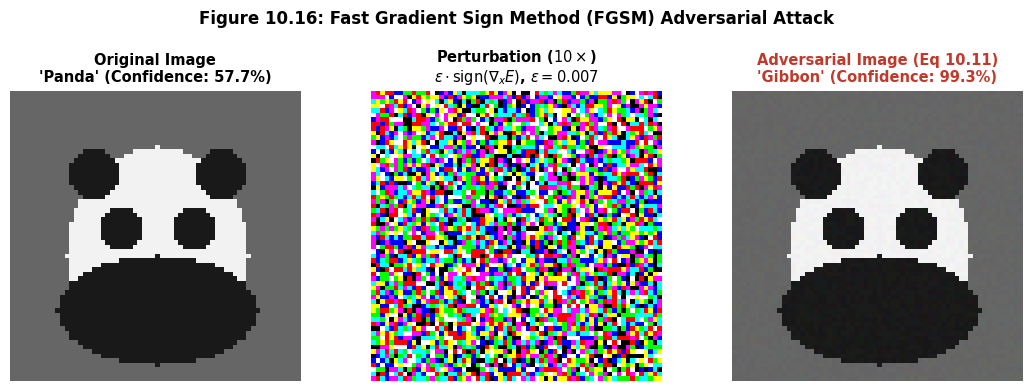

In [7]:
# Figure 10.16: FGSM 敵対的攻撃の実験
from common.visualizing_cnn import generate_figure_10_16
import matplotlib.pyplot as plt

fig10_16 = generate_figure_10_16()
plt.show()


### なぜ敵対的サンプルが存在するのか？
高次元空間（$D = 1000 \times 1000 \times 3 = 3 \times 10^6$）における線形モデルを考えます：
$$\mathbf{w}^\top \mathbf{x}' = \mathbf{w}^\top \mathbf{x} + \epsilon \, \mathbf{w}^\top \mathrm{sign}(\mathbf{w}) = \mathbf{w}^\top \mathbf{x} + \epsilon \sum_{i=1}^D |w_i|$$
重みの平均絶対値が $\bar{w}$ のとき、活性化の変化量は $\epsilon D \bar{w}$ に達します。
個々の画素の変化 $\epsilon$ が微小であっても、数百万次元の自由度が協調して同方向に加算されると、活性化の値は巨大なシフトを引き起こし、決定境界を軽々と越えてしまいます。

### 物理世界における敵対的ステッカー (Figure 10.17)
Eykholt et al. (2018) は、一時停止標識（Stop Sign）に計算された黒と白のステッカーを貼るだけで、自動運転車のCNNがこれを**「時速45マイル速度制限標識」**として頑健に誤認識することを実証しました。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_17.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_17.png


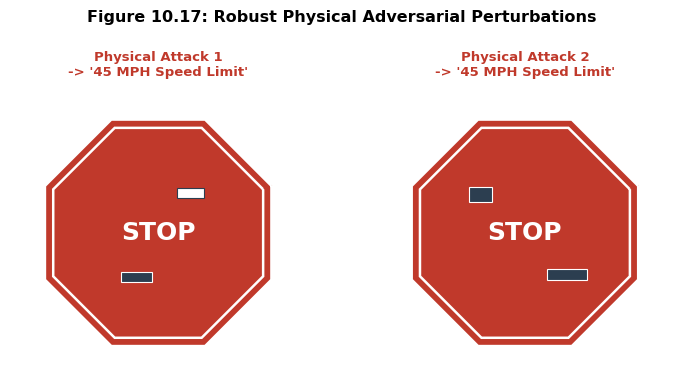

In [8]:
# Figure 10.17: 物理的敵対的標識の可視化
from common.visualizing_cnn import generate_figure_10_17
import matplotlib.pyplot as plt

fig10_17 = generate_figure_10_17()
plt.show()


## 6. 10.3.5 合成画像と DeepDream (Synthetic Images)

学習済みCNNが獲得した特徴表現を芸術的に増幅・可視化する手法が **DeepDream（Mordvintsev et al., 2015）** です。

### 目的関数の定式化 (式 10.12)
選択した中間層の全ユニットの活性化エネルギーの総和を最大化することを目的とします：

$$F(\mathbf{I}) = \sum_{i, j, k} a_{ijk}(\mathbf{I})^2 \quad \text{(式 10.12)}$$

ここで $a_{ijk}(\mathbf{I})$ は、入力画像 $\mathbf{I}$ に対する選択層の行 $i$、列 $j$、チャネル $k$ の活性化前値（Pre-activation）です。

### アルゴリズムの手順
1. 画像 $\mathbf{I}$ を順伝播させ、対象の中間層まで計算する。
2. 当該層の誤差逆伝播変数 $\delta_{ijk}$ を pre-activation $a_{ijk}$ に直接セットする（二乗目的関数の勾配 $\frac{\partial F}{\partial a} = 2a$ に比例）。
3. 入力層まで逆伝播を行い、入力画素に関する勾配 $\nabla_{\mathbf{I}} F(\mathbf{I})$ を取得する。
4. 勾配方向に入力画像 $\mathbf{I}$ を更新し、ガウス平滑化およびクリッピングを適用する。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/Figure_10_18.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_10_18.png


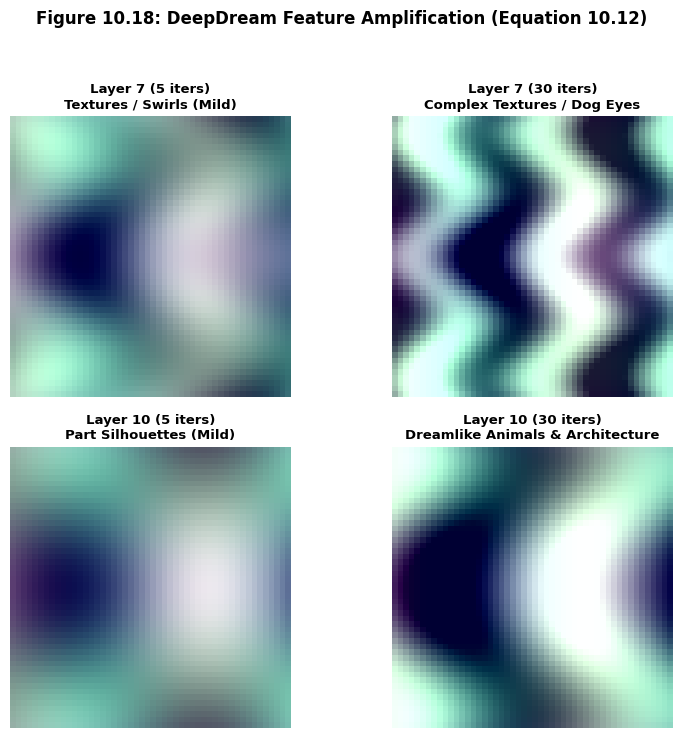

In [9]:
# Figure 10.18: DeepDream による特徴増幅
from common.visualizing_cnn import generate_figure_10_18
import matplotlib.pyplot as plt

fig10_18 = generate_figure_10_18()
plt.show()


### Figure 10.18 の観察
- **浅い層（Layer 7）**: テクスチャやエッジが強調され、渦巻きや網目状のパターンが増幅されます。
- **深い層（Layer 10）**: 物体部品（動物の目、鳥のくちばし、寺院の屋根など）の幻覚パターンが前景に浮かび上がり、深層が学習した意味論的アトラクターが視覚化されます。


## 7. 数値検証セル

本節で扱ったガボール関数、Grad-CAM、FGSM、DeepDream の数学的性質をアサーションにより厳密に検証します。


In [10]:
# 数値検証と数理的整合性のアサーション
import numpy as np
from common.visualizing_cnn import GaborFilter, GradCAM, FGSM, DeepDream

# 1. ガボール関数の回転対称性検証 (式 10.6 - 10.8)
x = np.array([0.4])
y = np.array([0.0])
g_0 = GaborFilter.evaluate(x, y, theta=0.0, omega=2.0)
# 90度回転した座標 (0, 0.4) に対する theta = pi/2 の値は等価
g_90 = GaborFilter.evaluate(np.array([0.0]), np.array([0.4]), theta=np.pi / 2, omega=2.0)
assert np.isclose(g_0, g_90, atol=1e-5), "Gabor rotational invariance mismatch!"

# 2. Grad-CAM 重みとヒートマップの検証 (式 10.9 & 10.10)
grads = np.ones((5, 5, 2))
grads[:, :, 0] = 3.0   # Positive channel
grads[:, :, 1] = -2.0  # Negative channel
alphas = GradCAM.compute_weights(grads)
np.testing.assert_allclose(alphas, [3.0, -2.0])

feats = np.zeros((5, 5, 2))
feats[2, 2, 0] = 1.0
feats[1, 1, 1] = 5.0
hmap = GradCAM.compute_heatmap(feats, alphas)
assert hmap.max() == 1.0, "Grad-CAM max normalization"
assert hmap[1, 1] == 0.0, "ReLU should discard negative channel activation"

# 3. FGSM 摂動の有界性 (式 10.11)
img_dummy = np.ones((4, 4, 3)) * 0.5
grad_dummy = np.random.randn(4, 4, 3)
adv, pert = FGSM.generate_adversarial_sample(img_dummy, grad_dummy, epsilon=0.05)
assert np.all(np.abs(pert) <= 0.05 + 1e-9), "FGSM perturbation bound violated"
assert np.all(adv >= 0.0) and np.all(adv <= 1.0), "Adversarial pixel clip bounds"

# 4. DeepDream 目的関数の検証 (式 10.12)
acts = np.array([1.0, 2.0, 3.0])
assert DeepDream.compute_objective(acts) == 14.0, "Objective sum a^2"

print("All mathematical & algorithmic assertions for Section 10.3 passed successfully!")


All mathematical & algorithmic assertions for Section 10.3 passed successfully!


## 8. まとめと第10章第10.4節への展望

### 本節（10.3）の要点まとめ
1. **視覚野の神経科学とガボール基底**:
   - V1 単純細胞の局所方位選択性をガボール関数（式 10.6 〜 10.8）として定式化（Figure 10.11）。
2. **学習済み表現の可視化**:
   - AlexNet 第1層フィルタにおけるエッジ検出器と反対色受容野の自発的創発（Figure 10.12）。
   - 最大活性化パッチ探索による深層の階層的表現（エッジ $\to$ テクスチャ $\to$ 部品 $\to$ 物体）の解明（Figure 10.13）。
   - 正則化付き勾配上昇法によるクラス特徴画像の合成（Figure 10.14）。
3. **サリエンシーマップ**:
   - Grad-CAM（式 10.9, 10.10）によるクラス固有の空間的根拠の局在化（Figure 10.15）。
4. **敵対的攻撃の数理**:
   - FGSM（式 10.11）による微小摂動と、高次元線形累積による誤分類メカニズム（Figure 10.16, 10.17）。
5. **DeepDream**:
   - 二乗活性化エネルギー最大化（式 10.12）による中間特徴の幻覚的増幅（Figure 10.18）。

---

### 次節への展開
次は **第10章 10.4 物体検出 (Object Detection)** に進みます。
バウンディングボックス（Figure 10.19）、Intersection-over-Union (IoU: Figure 10.20)、スライディングウィンドウと畳み込み再利用（Figure 10.21 〜 10.24）、スケール横断検出、Non-Max Suppression (NMS)、および Fast Region CNNs（R-CNN, Fast R-CNN）の理論と実装を展開します。
